In [1]:
from datetime import datetime
import pandas as pd
import yfinance as yf
import requests
import zipfile
from io import BytesIO
import numpy as np
import json

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# A. Brent 가격이랑 관련된 것만 넣어서 baseline

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [ ]:
# ============================
# 1. Windowing Function
# ============================

def create_windows(df_scaled, df_original, target_col="brent_ret_5d", seq_len=30):
    """
    df_scaled  : 입력 피처들 (scaling된 데이터)
    df_original: 원본 데이터 (close값 + 원본 return 포함)
    target_col : 예측할 컬럼 (return)
    """
    X, y, close_today = [], [], []

    scaled_vals = df_scaled.values
    cols = df_scaled.columns.tolist()

    # 가격 복원용 close는 원본 사용
    original_close = df_original["brent_close"].values
    original_target = df_original[target_col].values   # ★ 원본 return 가져오기

    for i in range(len(df_scaled) - seq_len - 1):

        # 입력 시퀀스 (scaled)
        X.append(scaled_vals[i:i+seq_len])

        # target은 scaled 사용하면 절대 안됨!
        y.append(original_target[i+seq_len])

        # price 복원용 원본 close
        close_today.append(original_close[i+seq_len])

    return np.array(X), np.array(y), np.array(close_today)


# ============================
# 2. Dataset + Dataloader
# ============================

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ============================
# 3. Bi-GRU Model
# ============================

class BiGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim * 2, 1)  # BiGRU -> 2 * hidden

    def forward(self, x):
        out, _ = self.gru(x)          # out: (batch, seq_len, hidden*2)
        last = out[:, -1, :]          # 마지막 시점
        return self.fc(last)


# ============================
# 4. Train Function
# ============================

def train_model(model, train_loader, val_loader, epochs=30, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            pred = model(X_batch)
            loss = criterion(pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                pred = model(X_val)
                loss = criterion(pred, y_val)
                val_loss += loss.item()

        print(f"[Epoch {epoch:02d}] train={train_loss:.5f}, val={val_loss:.5f}")


# ============================
# 5. Predict & Price Restoration
# ============================

def predict_and_restore_price(model, X, close_today):
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        pred_ret = model(X_tensor).numpy().reshape(-1)

    # price 복원
    pred_price = close_today * (1 + pred_ret)
    return pred_ret, pred_price


# ============================
# 6. 시각화
# ============================


def plot_results(y_test, pred_ret, close_test, pred_price):
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # --- Return 시각화 ---
    axes[0].plot(y_test, label="Actual Return", linewidth=2)
    axes[0].plot(pred_ret, label="Predicted Return", linewidth=2)
    axes[0].set_title("Brent 1D Return Prediction")
    axes[0].legend()
    axes[0].grid(True)

    # --- Price 시각화 ---
    axes[1].plot(close_test, label="Actual Close Price", linewidth=2)
    axes[1].plot(pred_price, label="Predicted Close Price", linewidth=2)
    axes[1].set_title("Brent Close Price (Restored from Return)")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

def evaluate_predictions(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    # 방향성 정확도
    direction = np.mean(np.sign(y_true) == np.sign(y_pred))

    print("\n===== Evaluation =====")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE : {mae:.6f}")
    print(f"Direction Accuracy: {direction:.4f}")

    return rmse, mae, direction

# ============================
# 7. Full Pipeline
# ============================

def run_bigru_pipeline(df, seq_len=30, target_col="brent_ret_5d"):

    # 1) 입력용 feature에서 close 제거
    df_input = df.drop(columns=["brent_close", "wti_close"], errors="ignore")


    # 2) 스케일링 (input only)
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df_input),
        index=df.index,
        columns=df_input.columns
    )

    # 3) window 생성 (y는 원본 return, close_today도 원본)
    X, y, close_today = create_windows(
        df_scaled,
        df_original=df,
        target_col=target_col,
        seq_len=seq_len
    )

    # ----- split -----
    train_size = int(len(X) * 0.7)
    val_size   = int(len(X) * 0.15)

    X_train, y_train = X[:train_size], y[:train_size]
    X_val, y_val     = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
    X_test, y_test   = X[train_size+val_size:], y[train_size+val_size:]
    close_test       = close_today[train_size+val_size:]

    # ----- dataloader -----
    train_ds = TimeSeriesDataset(X_train, y_train)
    val_ds   = TimeSeriesDataset(X_val, y_val)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=32)

    # ----- model -----
    input_dim = X.shape[2]
    model = BiGRU(input_dim=input_dim, hidden_dim=64, num_layers=1)

    # ----- train -----
    train_model(model, train_loader, val_loader, epochs=40, lr=1e-3)

    # ----- test prediction -----
    pred_ret, pred_price = predict_and_restore_price(model, X_test, close_test)

    # ----- evaluation -----
    rmse, mae, direction = evaluate_predictions(y_test, pred_ret)

    # ----- plot -----
    plot_results(y_test, pred_ret, close_test, pred_price)

    return {
        "model": model,
        "metrics": {
            "rmse": rmse,
            "mae": mae,
            "direction_accuracy": direction
        },
        "prediction": {
            "y_test": y_test,
            "pred_ret": pred_ret,
            "pred_price": pred_price
        },
        "scaler": scaler
    }


In [18]:
def make_brent_wti_features(start="2013-09-01", end=None):
    brent = yf.download("BZ=F", start=start, end=end, auto_adjust=False, progress=False)
    wti   = yf.download("CL=F", start=start, end=end, auto_adjust=False, progress=False)

    brent = brent.rename(columns=str.lower)
    wti   = wti.rename(columns=str.lower)

    df = pd.DataFrame(index=brent.index)
    df["brent_close"] = brent["close"]
    df["wti_close"]   = wti["close"].reindex(df.index)

    # Spread (가장 중요한 가격신호)
    df["brent_wti_spread"] = df["brent_close"] - df["wti_close"]

    # === Brent returns ===
    df["brent_ret_1d"]  = df["brent_close"].pct_change(1)
    df["brent_ret_5d"]  = df["brent_close"].pct_change(5)
    df["brent_ret_20d"] = df["brent_close"].pct_change(20)

    # === WTI returns === (추가)
    df["wti_ret_1d"] = df["wti_close"].pct_change(1)
    df["wti_ret_5d"] = df["wti_close"].pct_change(5)

    # === Brent MA ===
    df["brent_ma_5"]  = df["brent_close"].rolling(5).mean()
    df["brent_ma_20"] = df["brent_close"].rolling(20).mean()
    df["brent_ma_60"] = df["brent_close"].rolling(60).mean()

    # === WTI MA === (추가)
    df["wti_ma_5"]  = df["wti_close"].rolling(5).mean()
    df["wti_ma_20"] = df["wti_close"].rolling(20).mean()
    df["wti_ma_60"] = df["wti_close"].rolling(60).mean()

    # === 변동성 proxy ===
    df["brent_vol_5d"] = df["brent_close"].pct_change().rolling(5).std()
    df["wti_vol_5d"]   = df["wti_close"].pct_change().rolling(5).std()

    df["high_low_range"] = (brent["high"] - brent["low"]) / brent["close"]

    return df.dropna()


features = make_brent_wti_features()
features = features[features.index >= "2014-01-01"]
print(features.tail())


            brent_close  wti_close  brent_wti_spread  brent_ret_1d  \
Date                                                                 
2025-11-13    63.009998  58.689999          4.320000      0.004784   
2025-11-14    64.389999  60.090000          4.299999      0.021901   
2025-11-17    64.199997  59.910000          4.289997     -0.002951   
2025-11-18    64.889999  60.740002          4.149998      0.010748   
2025-11-19    64.389999  60.189999          4.200001     -0.007705   

            brent_ret_5d  brent_ret_20d  wti_ret_1d  wti_ret_5d  brent_ma_5  \
Date                                                                          
2025-11-13     -0.005838       0.031936    0.003419   -0.012452   63.714000   
2025-11-14      0.011944       0.050579    0.023854    0.005690   63.866000   
2025-11-17      0.002185       0.052286   -0.002996   -0.003659   63.893999   
2025-11-18     -0.004144       0.058219    0.013854   -0.004915   63.839999   
2025-11-19      0.026790       0.02

C:\Users\SKAX\AppData\Local\Temp\ipykernel_1676\1702013477.py:21: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["wti_ret_1d"] = df["wti_close"].pct_change(1)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_1676\1702013477.py:22: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["wti_ret_5d"] = df["wti_close"].pct_change(5)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_1676\1702013477.py:36: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=

[Epoch 01] train=0.18351, val=0.01035
[Epoch 02] train=0.04929, val=0.01199
[Epoch 03] train=0.04946, val=0.01030
[Epoch 04] train=0.04611, val=0.00979
[Epoch 05] train=0.04619, val=0.01047
[Epoch 06] train=0.04517, val=0.01196
[Epoch 07] train=0.04769, val=0.01159
[Epoch 08] train=0.04322, val=0.00940
[Epoch 09] train=0.04591, val=0.00963
[Epoch 10] train=0.04450, val=0.01273
[Epoch 11] train=0.04481, val=0.01020
[Epoch 12] train=0.04012, val=0.01007
[Epoch 13] train=0.03901, val=0.01115
[Epoch 14] train=0.04140, val=0.01177
[Epoch 15] train=0.04864, val=0.01618
[Epoch 16] train=0.04738, val=0.01422
[Epoch 17] train=0.03867, val=0.01086
[Epoch 18] train=0.03941, val=0.01014
[Epoch 19] train=0.03772, val=0.01216
[Epoch 20] train=0.03608, val=0.00935
[Epoch 21] train=0.03926, val=0.01015
[Epoch 22] train=0.03744, val=0.01046
[Epoch 23] train=0.04136, val=0.01320
[Epoch 24] train=0.03641, val=0.00880
[Epoch 25] train=0.03503, val=0.00947
[Epoch 26] train=0.03509, val=0.01121
[Epoch 27] t

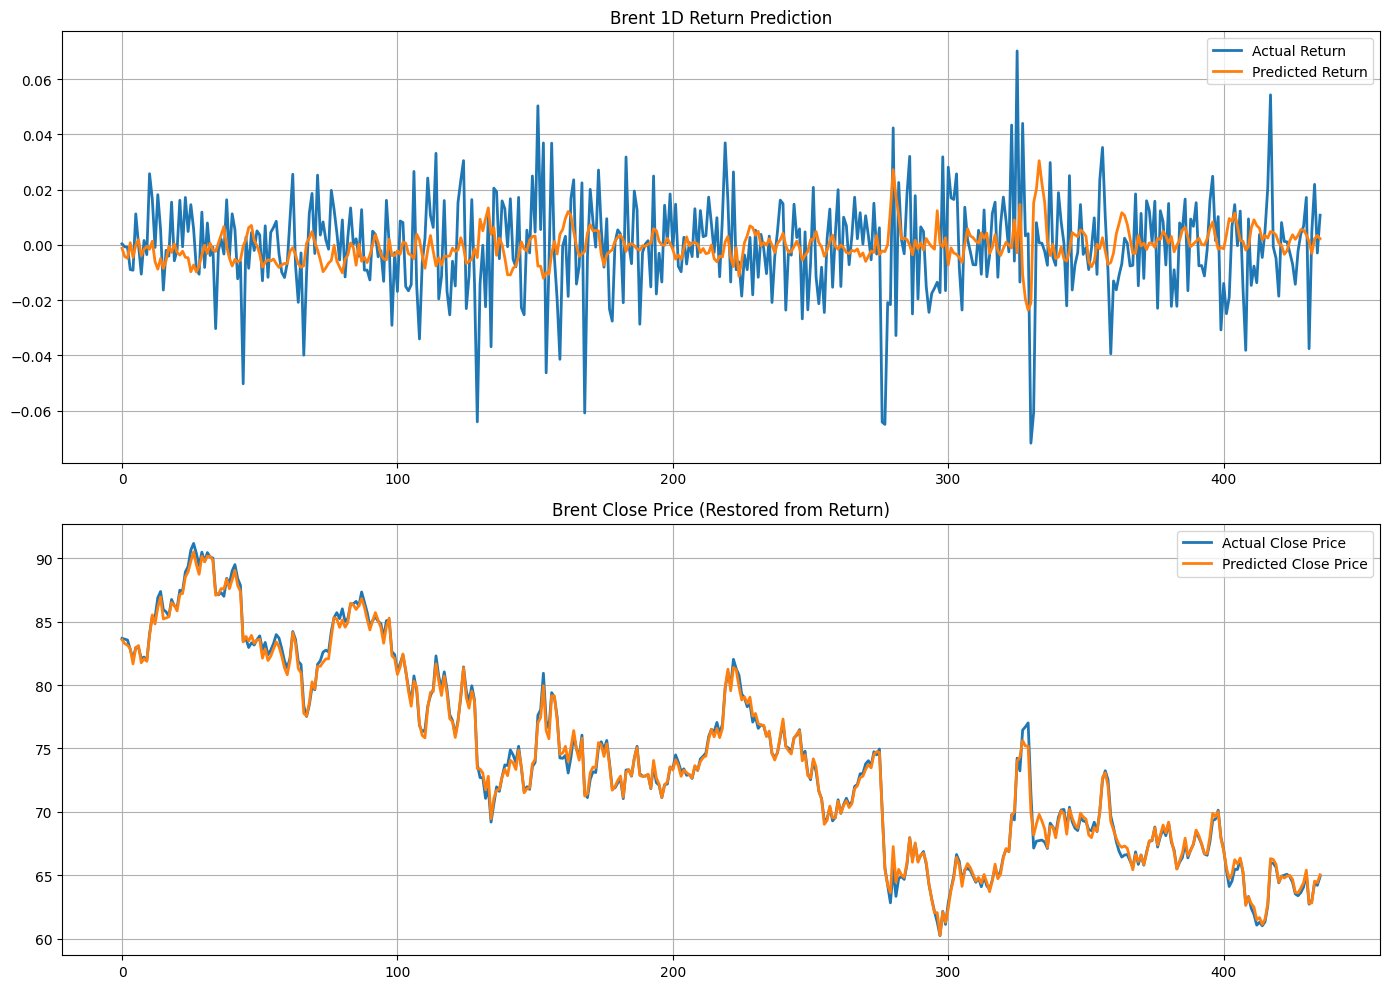

ValueError: too many values to unpack (expected 3)

In [ ]:
df = features.copy()
result = run_bigru_pipeline(df)
result

# B. EIA 추가

In [39]:
API_KEY = "m9fePZTks6kdpVDleRYzWYJMdZOXubKwwTHYuiPJ"

# ------------------------------
# 1. fetch functions (원본 그대로)
# ------------------------------

def fetch_crude_stock():
    url = "https://api.eia.gov/v2/seriesid/PET.WCESTUS1.W"
    params = {"api_key": API_KEY}
    r = requests.get(url, params=params)
    r.raise_for_status()
    js = r.json()

    df = pd.DataFrame(js["response"]["data"])
    df["period"] = pd.to_datetime(df["period"])
    df["value"] = pd.to_numeric(df["value"])
    df = df.sort_values("period")
    df = df.rename(columns={"value": "crude_stock_level"})
    return df[["period", "crude_stock_level"]]


def fetch_gas_stock_total():
    url = "https://api.eia.gov/v2/seriesid/PET.WGTSTUS1.W"
    params = {"api_key": API_KEY}
    r = requests.get(url, params=params)
    r.raise_for_status()
    js = r.json()

    df = pd.DataFrame(js["response"]["data"])
    df["period"] = pd.to_datetime(df["period"])
    df["value"] = pd.to_numeric(df["value"])
    df = df.sort_values("period")
    df = df.rename(columns={"value": "gas_stock_level"})
    return df[["period", "gas_stock_level"]]


def fetch_dist_stock_total():
    url = "https://api.eia.gov/v2/seriesid/PET.WDISTUS1.W"  # ★ 수정 (증류유)
    params = {"api_key": API_KEY}
    r = requests.get(url, params=params)
    r.raise_for_status()
    js = r.json()

    df = pd.DataFrame(js["response"]["data"])
    df["period"] = pd.to_datetime(df["period"])
    df["value"] = pd.to_numeric(df["value"])
    df = df.sort_values("period")
    df = df.rename(columns={"value": "dist_stock_level"})
    return df[["period", "dist_stock_level"]]


# ------------------------------
# 2. Index 설정 도우미
# ------------------------------

def set_period_index(df, col):
    out = df.copy()
    out["period"] = pd.to_datetime(out["period"])
    out = out.set_index("period").sort_index()
    return out[[col]]


# ------------------------------
# 3. EIA Load + Derived Features 생성
# ------------------------------

def load_eia_with_features():
    # (1) fetch
    crude = fetch_crude_stock()
    gas = fetch_gas_stock_total()
    dist = fetch_dist_stock_total()

    # (2) indexing
    crude_i = set_period_index(crude, "crude_stock_level")
    gas_i   = set_period_index(gas, "gas_stock_level")
    dist_i  = set_period_index(dist, "dist_stock_level")

    # (3) merge
    stocks = pd.concat([crude_i, gas_i, dist_i], axis=1)

    # -------------------------
    # 파생변수 생성
    # -------------------------

    # (A) WoW 변화량
    stocks["crude_stock_wow_change"] = stocks["crude_stock_level"].diff()
    stocks["gas_stock_wow_change"]   = stocks["gas_stock_level"].diff()
    stocks["dist_stock_wow_change"]  = stocks["dist_stock_level"].diff()

    # (B) 5년 평균 (52주 x 5)
    win_5yr = 52 * 5

    stocks["crude_5yr_avg"] = stocks["crude_stock_level"].rolling(win_5yr).mean()
    stocks["gas_5yr_avg"]   = stocks["gas_stock_level"].rolling(win_5yr).mean()
    stocks["dist_5yr_avg"]  = stocks["dist_stock_level"].rolling(win_5yr).mean()

    # (C) 5년 평균 대비 편차
    stocks["crude_vs_5yr_avg"] = stocks["crude_stock_level"] - stocks["crude_5yr_avg"]
    stocks["gas_vs_5yr_avg"]   = stocks["gas_stock_level"] - stocks["gas_5yr_avg"]
    stocks["dist_vs_5yr_avg"]  = stocks["dist_stock_level"] - stocks["dist_5yr_avg"]

    # (D) Z-score (52주 표준편차)
    stocks["crude_zscore"] = (stocks["crude_vs_5yr_avg"] /
                              stocks["crude_stock_level"].rolling(52).std())

    stocks["gas_zscore"] = (stocks["gas_vs_5yr_avg"] /
                            stocks["gas_stock_level"].rolling(52).std())

    stocks["dist_zscore"] = (stocks["dist_vs_5yr_avg"] /
                             stocks["dist_stock_level"].rolling(52).std())

    return stocks


# ------------------------------
# 4. 가격 feature df에 merge하는 함수
# ------------------------------

def merge_eia_to_features(features_df):
    """
    features_df: Brent/WTI 기반 feature 만들던 df (daily)
    """

    # 1) 원본 EIA weekly
    eia = load_eia_with_features()

    # 2) weekly → daily
    # 발표일 값이 다음 발표일까지 유지되도록 확실하게 forward fill
    eia_daily = eia.resample("1D").ffill()

    # 3) price df index가 datetime인지 보정
    features_df = features_df.copy()
    features_df.index = pd.to_datetime(features_df.index)

    # 4) price timeline에 맞추기
    eia_daily = eia_daily.reindex(features_df.index).ffill()

    # 5) merge
    merged = pd.concat([features_df, eia_daily], axis=1)

    return merged

In [40]:
features = make_brent_wti_features()
features = features[features.index >= "2014-01-01"]

features_b = merge_eia_to_features(features)
features_b.head()

C:\Users\SKAX\AppData\Local\Temp\ipykernel_1676\1702013477.py:21: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["wti_ret_1d"] = df["wti_close"].pct_change(1)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_1676\1702013477.py:22: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["wti_ret_5d"] = df["wti_close"].pct_change(5)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_1676\1702013477.py:36: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=

,brent_close,wti_close,brent_wti_spread,brent_ret_1d,brent_ret_5d,brent_ret_20d,wti_ret_1d,wti_ret_5d,brent_ma_5,brent_ma_20,brent_ma_60,wti_ma_5,wti_ma_20,wti_ma_60,brent_vol_5d,wti_vol_5d,high_low_range,crude_stock_level,gas_stock_level,dist_stock_level,crude_stock_wow_change,gas_stock_wow_change,dist_stock_wow_change,crude_5yr_avg,gas_5yr_avg,dist_5yr_avg,crude_vs_5yr_avg,gas_vs_5yr_avg,dist_vs_5yr_avg,crude_zscore,gas_zscore,dist_zscore
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-01-02,107.779999,95.440002,12.339996,-0.027256,-0.036819,-0.032930,-0.030278,-0.038097,110.790001,110.6705,109.391334,98.604001,97.9800,97.413000,0.011831,0.014810,0.033680,330695.0,220716.0,119147.0,-7007.0,844.0,5042.0,335195.292308,216338.500000,142926.357692,-4500.292308,4377.500000,-23779.357692,-0.350348,0.684699,-3.867273
2014-01-03,106.889999,93.959999,12.930000,-0.008258,-0.045455,-0.050879,-0.015507,-0.056153,109.772000,110.3840,109.356167,97.486000,97.8760,97.257167,0.010935,0.013672,0.017214,326737.0,226959.0,124973.0,-3958.0,6243.0,5826.0,335265.896154,216390.246154,142852.534615,-8528.896154,10568.753846,-17879.534615,-0.654926,1.698731,-2.955366
2014-01-06,106.730003,93.430000,13.300003,-0.001497,-0.048583,-0.046031,-0.005641,-0.068680,108.682001,110.1265,109.310667,96.108000,97.6875,97.083667,0.010182,0.009727,0.012836,326737.0,226959.0,124973.0,-3958.0,6243.0,5826.0,335265.896154,216390.246154,142852.534615,-8528.896154,10568.753846,-17879.534615,-0.654926,1.698731,-2.955366
2014-01-07,107.349998,93.669998,13.680000,0.005809,-0.034709,-0.032709,0.002569,-0.056602,107.910001,109.9450,109.271834,94.984000,97.5020,96.927667,0.012422,0.012333,0.007452,326737.0,226959.0,124973.0,-3958.0,6243.0,5826.0,335265.896154,216390.246154,142852.534615,-8528.896154,10568.753846,-17879.534615,-0.654926,1.698731,-2.955366
2014-01-08,107.150002,92.330002,14.820000,-0.001863,-0.032942,-0.039961,-0.014306,-0.061878,107.180000,109.7220,109.221667,93.766000,97.2360,96.741667,0.012569,0.012272,0.008493,326737.0,226959.0,124973.0,-3958.0,6243.0,5826.0,335265.896154,216390.246154,142852.534615,-8528.896154,10568.753846,-17879.534615,-0.654926,1.698731,-2.955366


[Epoch 01] train=0.34623, val=0.02865
[Epoch 02] train=0.05979, val=0.02492
[Epoch 03] train=0.04891, val=0.02851
[Epoch 04] train=0.04536, val=0.02259
[Epoch 05] train=0.04630, val=0.01570
[Epoch 06] train=0.04209, val=0.01541
[Epoch 07] train=0.04107, val=0.02267
[Epoch 08] train=0.04841, val=0.01216
[Epoch 09] train=0.04442, val=0.02156
[Epoch 10] train=0.05164, val=0.01407
[Epoch 11] train=0.04551, val=0.01096
[Epoch 12] train=0.04352, val=0.01529
[Epoch 13] train=0.03960, val=0.01201
[Epoch 14] train=0.03456, val=0.01168
[Epoch 15] train=0.03597, val=0.01655
[Epoch 16] train=0.03418, val=0.01220
[Epoch 17] train=0.03583, val=0.01083
[Epoch 18] train=0.04059, val=0.01236
[Epoch 19] train=0.03648, val=0.01122
[Epoch 20] train=0.03323, val=0.01340
[Epoch 21] train=0.03858, val=0.01889
[Epoch 22] train=0.03319, val=0.01534
[Epoch 23] train=0.03731, val=0.01174
[Epoch 24] train=0.03443, val=0.01776
[Epoch 25] train=0.03258, val=0.01849
[Epoch 26] train=0.03485, val=0.01164
[Epoch 27] t

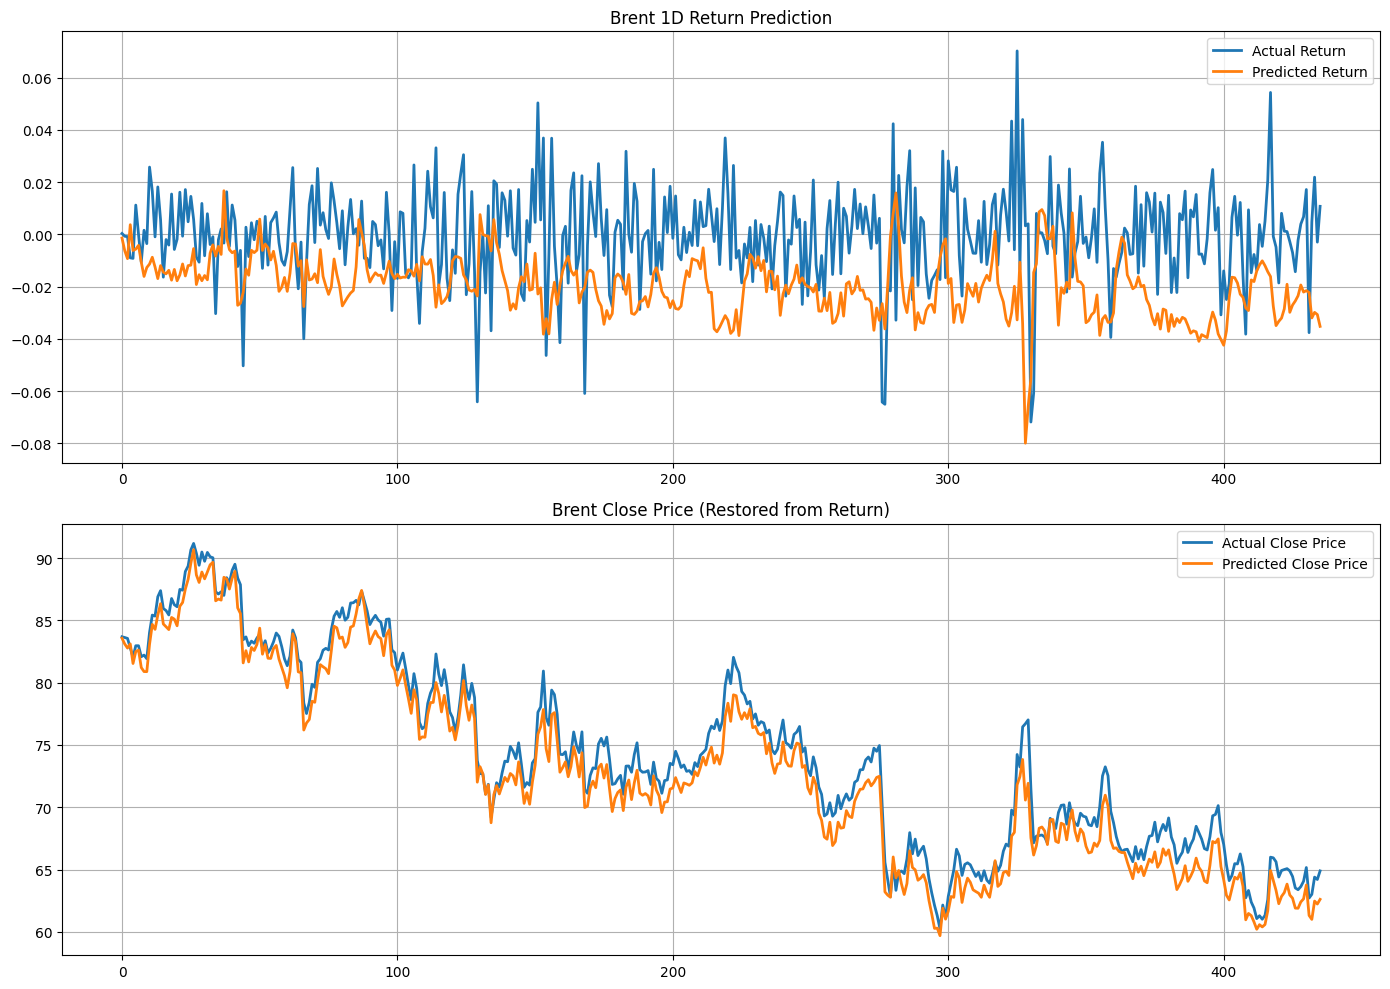

{'model': BiGRU(
   (gru): GRU(30, 64, batch_first=True, bidirectional=True)
   (fc): Linear(in_features=128, out_features=1, bias=True)
 ),
 'metrics': {'rmse': np.float64(0.028355276166696485),
  'mae': 0.02298093855619987,
  'direction_accuracy': np.float64(0.5022935779816514)},
 'prediction': {'y_test': array([ 0.00035862, -0.00071699, -0.00083712, -0.00897666, -0.00917877,
          0.01121402,  0.        , -0.01060749,  0.00158379, -0.00352756,
          0.02575684,  0.0165417 , -0.00093657,  0.01816268,  0.00563929,
         -0.0163653 , -0.00197787, -0.00408019,  0.01545124, -0.00576369,
         -0.00185511,  0.01614598, -0.00068593,  0.01715855,  0.00483581,
          0.01454956,  0.00573631, -0.00866514, -0.01062181,  0.01185423,
         -0.00817866,  0.00791174, -0.00386952, -0.00088792, -0.03032655,
         -0.0020621 ,  0.00206636, -0.00332227,  0.01632182, -0.00452388,
          0.01124751,  0.00550498, -0.01229049, -0.00610861, -0.05030729,
          0.00275642, -0.00

In [41]:
df = features_b.copy()
result = run_bigru_pipeline(df)
result

# B-1 EIA 데이터에서 파생변수만 쓰기

In [42]:
cols_to_remove = [
    "crude_stock_level", "gas_stock_level", "dist_stock_level",
    "crude_imports", "crude_exports", "net_imports",
    "prod_weekly", "prod_4w_ma", "prod_wow_change",
    "import_4w_ma",
    "refinery_run_rate"
]
features_b_1 = features_b.drop(columns=[c for c in features_b.columns 
                                      if any(k in c for k in [
                                          "stock_", "imports", "export", 
                                          "prod_", "refinery"
                                      ])])


[Epoch 01] train=0.15120, val=0.01270
[Epoch 02] train=0.05576, val=0.01117
[Epoch 03] train=0.05576, val=0.01224
[Epoch 04] train=0.05994, val=0.01582
[Epoch 05] train=0.05009, val=0.01162
[Epoch 06] train=0.04666, val=0.01115
[Epoch 07] train=0.04678, val=0.01252
[Epoch 08] train=0.04618, val=0.01180
[Epoch 09] train=0.04424, val=0.01170
[Epoch 10] train=0.03859, val=0.01358
[Epoch 11] train=0.03755, val=0.01018
[Epoch 12] train=0.03881, val=0.01153
[Epoch 13] train=0.04060, val=0.00987
[Epoch 14] train=0.03715, val=0.00891
[Epoch 15] train=0.04467, val=0.01065
[Epoch 16] train=0.03966, val=0.01068
[Epoch 17] train=0.03748, val=0.01255
[Epoch 18] train=0.03750, val=0.01066
[Epoch 19] train=0.03404, val=0.01017
[Epoch 20] train=0.03698, val=0.00926
[Epoch 21] train=0.03664, val=0.00953
[Epoch 22] train=0.03903, val=0.01015
[Epoch 23] train=0.03697, val=0.01147
[Epoch 24] train=0.03846, val=0.01087
[Epoch 25] train=0.03742, val=0.01132
[Epoch 26] train=0.03512, val=0.01146
[Epoch 27] t

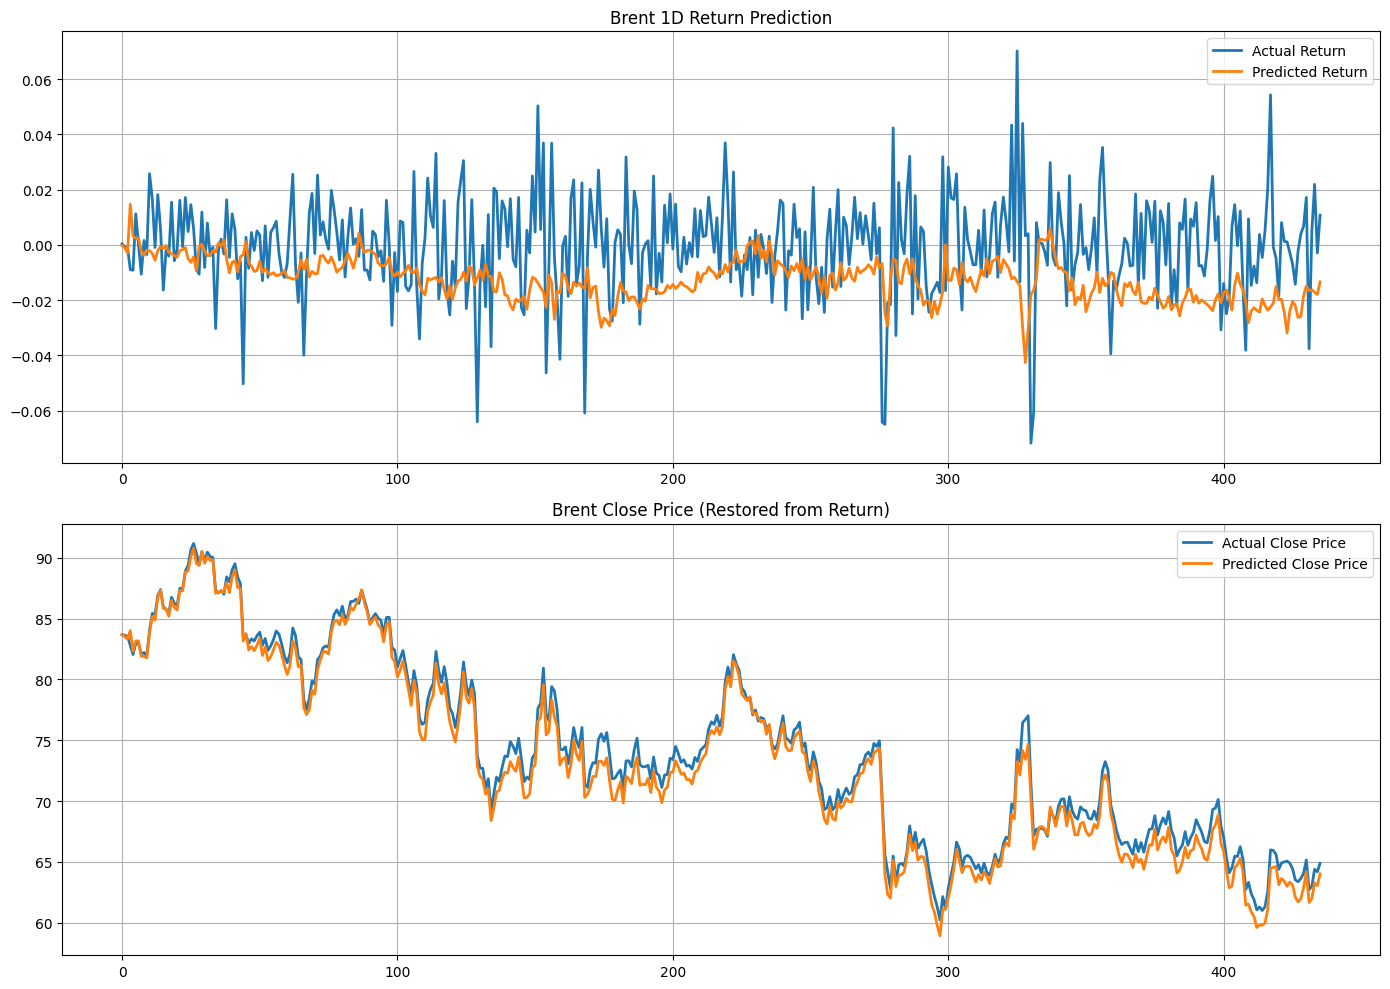

{'model': BiGRU(
   (gru): GRU(24, 64, batch_first=True, bidirectional=True)
   (fc): Linear(in_features=128, out_features=1, bias=True)
 ),
 'metrics': {'rmse': np.float64(0.022432404966388198),
  'mae': 0.017522440436603837,
  'direction_accuracy': np.float64(0.5)},
 'prediction': {'y_test': array([ 0.00035862, -0.00071699, -0.00083712, -0.00897666, -0.00917877,
          0.01121402,  0.        , -0.01060749,  0.00158379, -0.00352756,
          0.02575684,  0.0165417 , -0.00093657,  0.01816268,  0.00563929,
         -0.0163653 , -0.00197787, -0.00408019,  0.01545124, -0.00576369,
         -0.00185511,  0.01614598, -0.00068593,  0.01715855,  0.00483581,
          0.01454956,  0.00573631, -0.00866514, -0.01062181,  0.01185423,
         -0.00817866,  0.00791174, -0.00386952, -0.00088792, -0.03032655,
         -0.0020621 ,  0.00206636, -0.00332227,  0.01632182, -0.00452388,
          0.01124751,  0.00550498, -0.01229049, -0.00610861, -0.05030729,
          0.00275642, -0.00848571,  0.004

In [44]:
df = features_b_1.copy()
result = run_bigru_pipeline(df)
result

# C. COT 추가

In [48]:
def fetch_cot_raw(start_year=2009, end_year=2025):
    base_url = "https://www.cftc.gov/files/dea/history/fut_disagg_txt_{}.zip"
    all_df = []

    for year in range(start_year, end_year + 1):
        url = base_url.format(year)

        try:
            res = requests.get(url)
            res.raise_for_status()

            with zipfile.ZipFile(BytesIO(res.content)) as z:
                for name in z.namelist():
                    if name.endswith(".txt"):
                        df = pd.read_csv(z.open(name), header=None)
                        df["year"] = year
                        all_df.append(df)

        except:
            pass  # 조용히 skip

    if len(all_df) == 0:
        raise RuntimeError("COT raw 다운로드 실패")

    df_all = pd.concat(all_df, ignore_index=True)
    return df_all

def extract_cot_features(df_all):
    """
    df_all: CFTC disagg futures raw merged
    반환: cot_daily (날짜 index)
    """

    # ----- 헤더 처리 -----
    if df_all.iloc[0, 0] == "Market_and_Exchange_Names":
        df_all.columns = df_all.iloc[0]
        df_all = df_all.drop(index=0).reset_index(drop=True)

    df_all.columns = [str(c).strip() for c in df_all.columns]
    df_all = df_all.rename(columns=lambda x: x.replace("-", "_").replace(" ", "_"))

    # 날짜 컬럼 자동 탐색
    date_col = next((c for c in df_all.columns if "report_date" in c.lower()), None)
    df_all["date"] = pd.to_datetime(df_all[date_col], errors="coerce")

    # 핵심 포지션 컬럼
    mm_long = "M_Money_Positions_Long_All"
    mm_short = "M_Money_Positions_Short_All"
    prod_short = "Prod_Merc_Positions_Short_All"
    oi_col = "Open_Interest_All"

    # 숫자 처리
    for col in [mm_long, mm_short, prod_short, oi_col]:
        if col in df_all.columns:
            df_all[col] = pd.to_numeric(df_all[col], errors="coerce")

    # 시장명 소문자
    df_all["Market_and_Exchange_Names"] = (
        df_all["Market_and_Exchange_Names"].astype(str).str.lower()
    )

    # WTI만 필터링
    wti = df_all[
        df_all["Market_and_Exchange_Names"].str.contains("crude oil, light sweet", na=False)
    ].copy()

    # ----- 피처 생성 -----
    wti = (
        wti.sort_values("date")
           .groupby("date", as_index=False)
           .last()
    )

    wti["wti_mm_net_long"] = wti[mm_long] - wti[mm_short]
    wti["wti_mm_net_long_ratio"] = wti["wti_mm_net_long"] / wti[oi_col]
    wti["wti_producer_hedge_ratio"] = wti[prod_short] / wti[oi_col]
    wti["wti_mm_position_change_wow"] = wti["wti_mm_net_long"].diff()
    wti["wti_sentiment_position"] = np.sign(wti["wti_mm_net_long"])

    cot_weekly = wti.set_index("date")[
        [
            "wti_mm_net_long",
            "wti_mm_net_long_ratio",
            "wti_producer_hedge_ratio",
            "wti_mm_position_change_wow",
            "wti_sentiment_position",
        ]
    ]

    # ----- 주간 → 일간 변환 -----
    cot_daily = cot_weekly.resample("D").ffill()
    return cot_daily

def add_cot_to_features(features_df, cot_daily):
    """
    features_df: Brent/WTI input feature dataframe
    cot_daily : extract_cot_features() output
    """

    # index가 datetime이어야 merge 안전
    df = features_df.copy()
    df.index = pd.to_datetime(df.index)

    cot_daily = cot_daily.copy()
    cot_daily.index = pd.to_datetime(cot_daily.index)

    # 일간 forward fill된 COT를 feature에 붙임
    merged = df.join(cot_daily, how="left")

    # 결측 채움 (초반 기간에 해당)
    merged = merged.fillna(method="ffill").fillna(method="bfill")

    return merged


C:\Users\SKAX\AppData\Local\Temp\ipykernel_1676\4176304119.py:15: DtypeWarning: Columns (1,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,131,132,147,148,149,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,188) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open(name), header=None)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_1676\4176304119.py:15: DtypeWarning: Columns (1,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,1

[Epoch 01] train=0.13849, val=0.01062
[Epoch 02] train=0.05827, val=0.01913
[Epoch 03] train=0.06460, val=0.01735
[Epoch 04] train=0.05595, val=0.00930
[Epoch 05] train=0.04830, val=0.01325
[Epoch 06] train=0.04457, val=0.01078
[Epoch 07] train=0.04257, val=0.01177
[Epoch 08] train=0.04024, val=0.01051
[Epoch 09] train=0.04102, val=0.00887
[Epoch 10] train=0.03770, val=0.01094
[Epoch 11] train=0.03845, val=0.01127
[Epoch 12] train=0.04295, val=0.01433
[Epoch 13] train=0.03849, val=0.00944
[Epoch 14] train=0.03868, val=0.01031
[Epoch 15] train=0.03986, val=0.00974
[Epoch 16] train=0.04173, val=0.00894
[Epoch 17] train=0.03395, val=0.00913
[Epoch 18] train=0.03358, val=0.01044
[Epoch 19] train=0.03564, val=0.01110
[Epoch 20] train=0.03514, val=0.00906
[Epoch 21] train=0.03561, val=0.01057
[Epoch 22] train=0.03393, val=0.01653
[Epoch 23] train=0.03526, val=0.01055
[Epoch 24] train=0.03596, val=0.01205
[Epoch 25] train=0.03349, val=0.00931
[Epoch 26] train=0.03410, val=0.01075
[Epoch 27] t

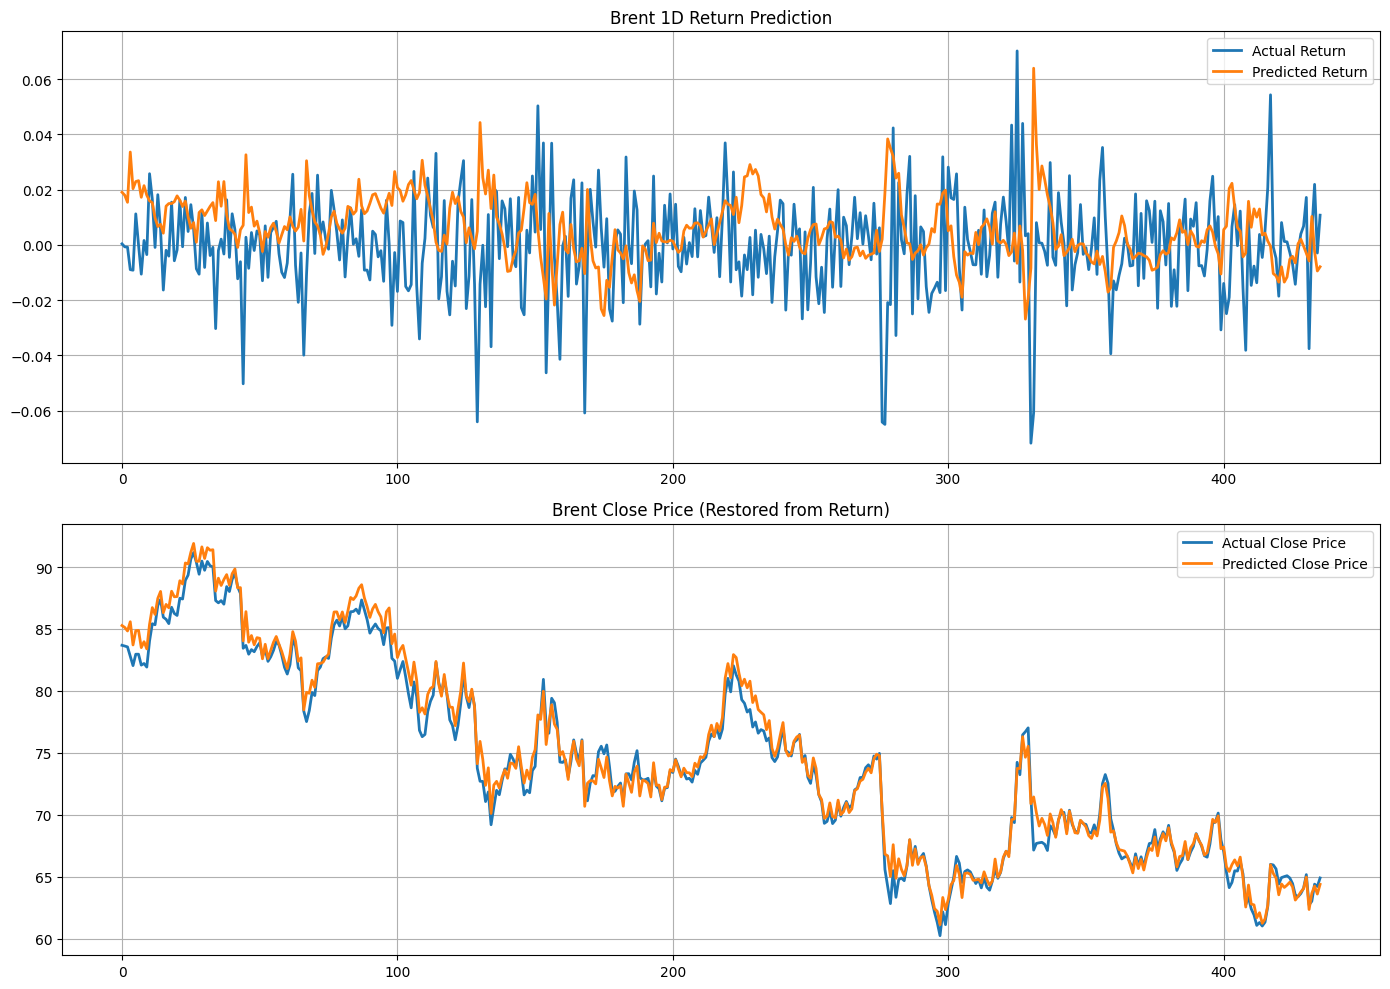

{'model': BiGRU(
   (gru): GRU(29, 64, batch_first=True, bidirectional=True)
   (fc): Linear(in_features=128, out_features=1, bias=True)
 ),
 'metrics': {'rmse': np.float64(0.02194773219622262),
  'mae': 0.01658897773597365,
  'direction_accuracy': np.float64(0.481651376146789)},
 'prediction': {'y_test': array([ 0.00035862, -0.00071699, -0.00083712, -0.00897666, -0.00917877,
          0.01121402,  0.        , -0.01060749,  0.00158379, -0.00352756,
          0.02575684,  0.0165417 , -0.00093657,  0.01816268,  0.00563929,
         -0.0163653 , -0.00197787, -0.00408019,  0.01545124, -0.00576369,
         -0.00185511,  0.01614598, -0.00068593,  0.01715855,  0.00483581,
          0.01454956,  0.00573631, -0.00866514, -0.01062181,  0.01185423,
         -0.00817866,  0.00791174, -0.00386952, -0.00088792, -0.03032655,
         -0.0020621 ,  0.00206636, -0.00332227,  0.01632182, -0.00452388,
          0.01124751,  0.00550498, -0.01229049, -0.00610861, -0.05030729,
          0.00275642, -0.0084

In [49]:
# 1) RAW 다운로드
df_all = fetch_cot_raw()

# 2) 파생변수 추출
cot_daily = extract_cot_features(df_all)

# 3) 기존 features에 merge
features_with_cot = add_cot_to_features(features_b_1, cot_daily)

# 4) GRU 실행
result = run_bigru_pipeline(features_with_cot)
result


# D. A + EIA + COT

C:\Users\SKAX\AppData\Local\Temp\ipykernel_1676\4176304119.py:15: DtypeWarning: Columns (1,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,131,132,147,148,149,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,188) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open(name), header=None)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_1676\4176304119.py:15: DtypeWarning: Columns (1,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,1

[Epoch 01] train=0.24087, val=0.01555
[Epoch 02] train=0.06984, val=0.02368
[Epoch 03] train=0.06966, val=0.01311
[Epoch 04] train=0.05542, val=0.01168
[Epoch 05] train=0.04817, val=0.01189
[Epoch 06] train=0.04228, val=0.01323
[Epoch 07] train=0.04417, val=0.01822
[Epoch 08] train=0.04111, val=0.01182
[Epoch 09] train=0.03995, val=0.01283
[Epoch 10] train=0.03813, val=0.01848
[Epoch 11] train=0.04189, val=0.01476
[Epoch 12] train=0.04004, val=0.01746
[Epoch 13] train=0.03828, val=0.01958
[Epoch 14] train=0.03465, val=0.01346
[Epoch 15] train=0.03762, val=0.02083
[Epoch 16] train=0.03394, val=0.01328
[Epoch 17] train=0.03350, val=0.01770
[Epoch 18] train=0.03267, val=0.01485
[Epoch 19] train=0.03340, val=0.01961
[Epoch 20] train=0.03230, val=0.01987
[Epoch 21] train=0.03208, val=0.01571
[Epoch 22] train=0.03878, val=0.01659
[Epoch 23] train=0.04002, val=0.02100
[Epoch 24] train=0.03112, val=0.02229
[Epoch 25] train=0.02892, val=0.01524
[Epoch 26] train=0.03002, val=0.01933
[Epoch 27] t

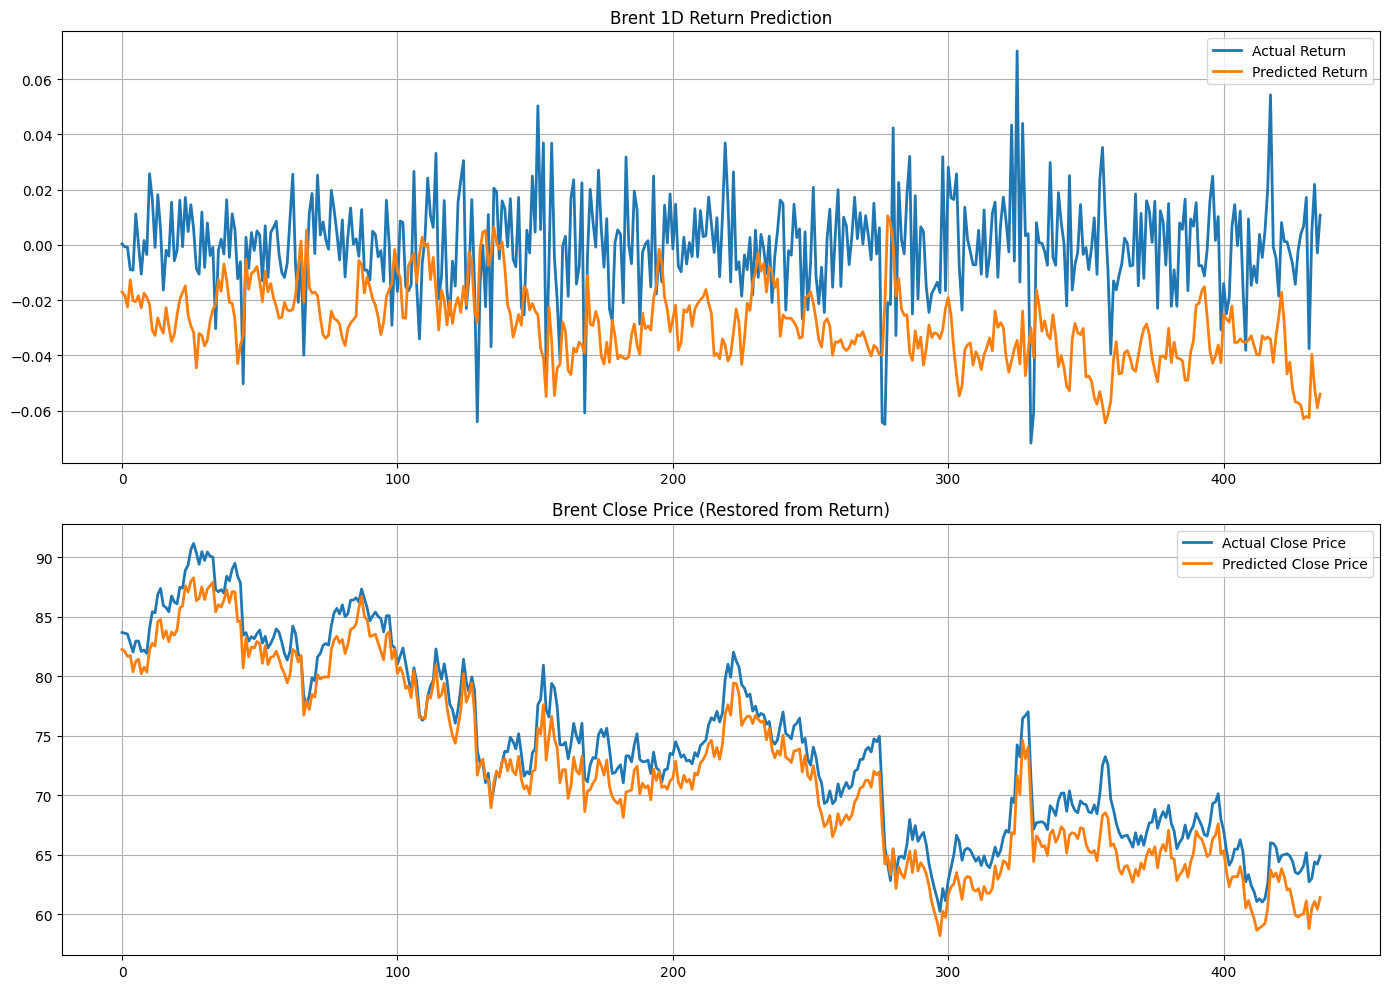

{'model': BiGRU(
   (gru): GRU(35, 64, batch_first=True, bidirectional=True)
   (fc): Linear(in_features=128, out_features=1, bias=True)
 ),
 'metrics': {'rmse': np.float64(0.03595649271575753),
  'mae': 0.031095077698182722,
  'direction_accuracy': np.float64(0.49770642201834864)},
 'prediction': {'y_test': array([ 0.00035862, -0.00071699, -0.00083712, -0.00897666, -0.00917877,
          0.01121402,  0.        , -0.01060749,  0.00158379, -0.00352756,
          0.02575684,  0.0165417 , -0.00093657,  0.01816268,  0.00563929,
         -0.0163653 , -0.00197787, -0.00408019,  0.01545124, -0.00576369,
         -0.00185511,  0.01614598, -0.00068593,  0.01715855,  0.00483581,
          0.01454956,  0.00573631, -0.00866514, -0.01062181,  0.01185423,
         -0.00817866,  0.00791174, -0.00386952, -0.00088792, -0.03032655,
         -0.0020621 ,  0.00206636, -0.00332227,  0.01632182, -0.00452388,
          0.01124751,  0.00550498, -0.01229049, -0.00610861, -0.05030729,
          0.00275642, -0.0

In [50]:
# 1) EIA 붙인 features_b
df_eia = features_b.copy()

# 2) COT raw 다운로드
df_all = fetch_cot_raw()

# 3) COT 파생변수 생성
cot_daily = extract_cot_features(df_all)

# 4) EIA + COT merge
df_final = add_cot_to_features(df_eia, cot_daily)

# 5) GRU 학습
result = run_bigru_pipeline(df_final)
result


# E. A + 뉴스 sentiment

In [53]:
def prepare_news_df(news_list):
    """
    news_list: JSON 데이터 리스트
    반환: date, sentiment만 정리된 DataFrame
    """
    rows = []
    for item in news_list:
        date = item.get("date_only") or item.get("date")  # date_only 우선 사용
        sent = None

        # sentiment 구조: { "score": -0.8, "explanation": "..."}
        if "sentiment" in item and isinstance(item["sentiment"], dict):
            sent = item["sentiment"].get("score", None)

        if date is not None and sent is not None:
            rows.append({"date": date, "sentiment": sent})

    df = pd.DataFrame(rows)
    df["date"] = pd.to_datetime(df["date"])
    return df

def aggregate_daily_sentiment(news_df):
    """
    date, sentiment 컬럼 가진 df → 일별 뉴스 피처 생성
    """
    daily = news_df.groupby("date").agg(
        news_sentiment_mean = ("sentiment", "mean"),
        news_sentiment_sum = ("sentiment", "sum"),
        news_sentiment_abs_sum = ("sentiment", lambda x: x.abs().sum()),
        news_count = ("sentiment", "count")
    )
    return daily

def merge_news_features(features_df, news_daily_df):
    """
    features_df : 브렌트/WTI/EIA/COT 등 포함한 기존 DF
    news_daily_df: aggregate_daily_sentiment 결과 DF
    """
    merged = features_df.merge(
        news_daily_df,
        left_index=True, 
        right_index=True,
        how="left"
    )

    # 뉴스 없는 날은 0으로 채우기
    merged = merged.fillna({
        "news_sentiment_mean": 0,
        "news_sentiment_sum": 0,
        "news_sentiment_abs_sum": 0,
        "news_count": 0
    })

    return merged


[Epoch 01] train=0.11230, val=0.01459
[Epoch 02] train=0.06373, val=0.01005
[Epoch 03] train=0.05756, val=0.01414
[Epoch 04] train=0.05293, val=0.01304
[Epoch 05] train=0.04856, val=0.01031
[Epoch 06] train=0.04754, val=0.01314
[Epoch 07] train=0.04448, val=0.01053
[Epoch 08] train=0.04196, val=0.01244
[Epoch 09] train=0.04263, val=0.01089
[Epoch 10] train=0.04055, val=0.00899
[Epoch 11] train=0.04364, val=0.00973
[Epoch 12] train=0.03956, val=0.01149
[Epoch 13] train=0.03873, val=0.01029
[Epoch 14] train=0.03944, val=0.00963
[Epoch 15] train=0.03894, val=0.00916
[Epoch 16] train=0.03855, val=0.00938
[Epoch 17] train=0.04020, val=0.01019
[Epoch 18] train=0.03658, val=0.01088
[Epoch 19] train=0.03497, val=0.01088
[Epoch 20] train=0.03504, val=0.00987
[Epoch 21] train=0.03639, val=0.01070
[Epoch 22] train=0.03421, val=0.00896
[Epoch 23] train=0.03499, val=0.00875
[Epoch 24] train=0.03297, val=0.00915
[Epoch 25] train=0.03534, val=0.01039
[Epoch 26] train=0.03392, val=0.01005
[Epoch 27] t

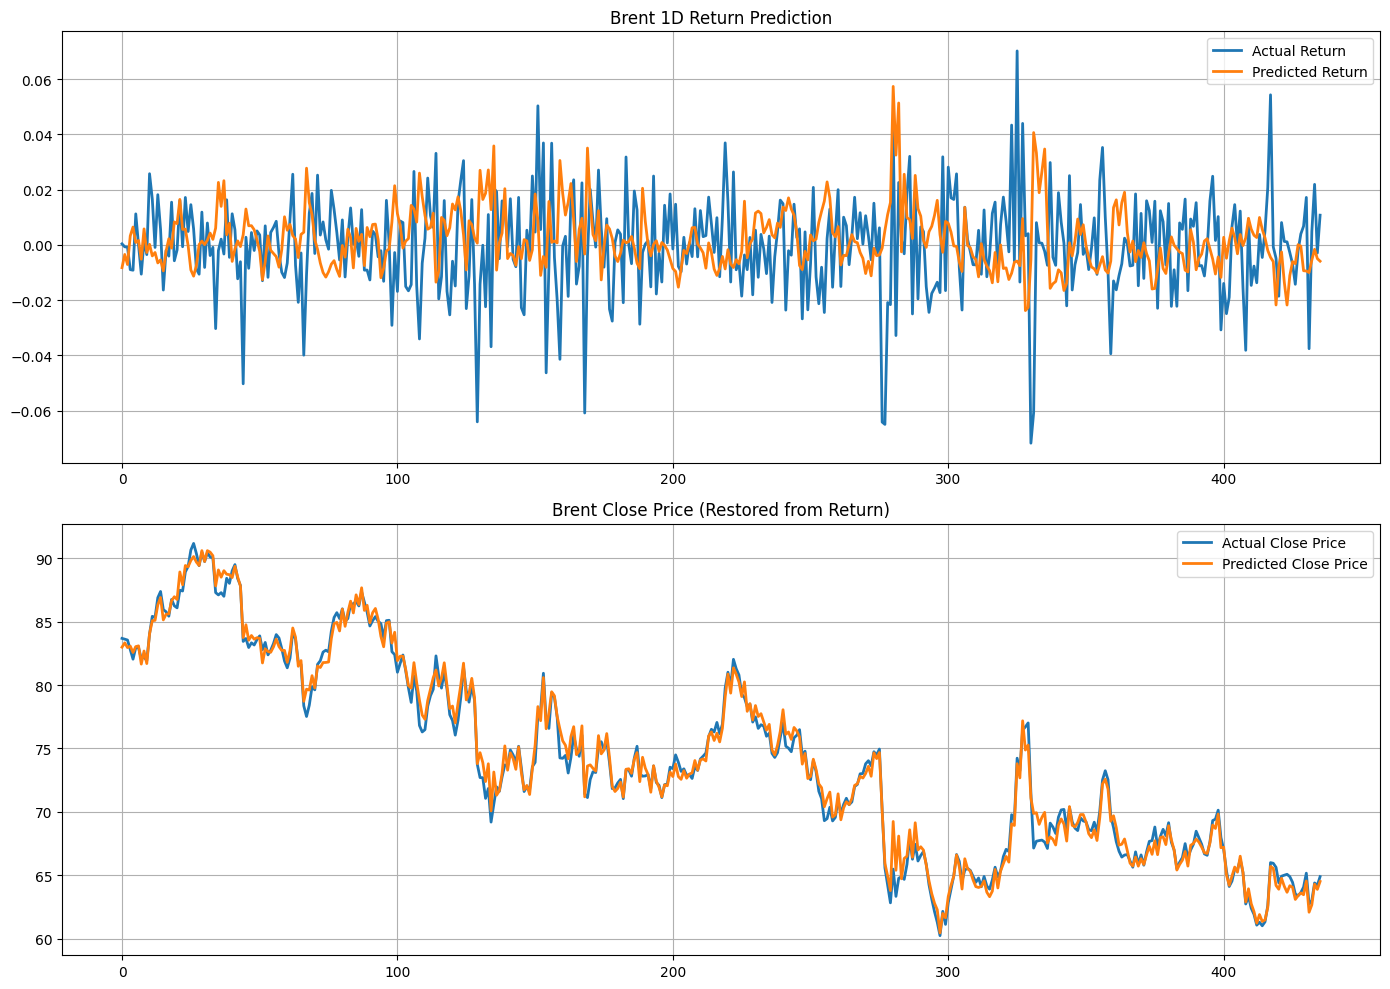

{'model': BiGRU(
   (gru): GRU(19, 64, batch_first=True, bidirectional=True)
   (fc): Linear(in_features=128, out_features=1, bias=True)
 ),
 'metrics': {'rmse': np.float64(0.020967449208091384),
  'mae': 0.015853439040977912,
  'direction_accuracy': np.float64(0.44495412844036697)},
 'prediction': {'y_test': array([ 0.00035862, -0.00071699, -0.00083712, -0.00897666, -0.00917877,
          0.01121402,  0.        , -0.01060749,  0.00158379, -0.00352756,
          0.02575684,  0.0165417 , -0.00093657,  0.01816268,  0.00563929,
         -0.0163653 , -0.00197787, -0.00408019,  0.01545124, -0.00576369,
         -0.00185511,  0.01614598, -0.00068593,  0.01715855,  0.00483581,
          0.01454956,  0.00573631, -0.00866514, -0.01062181,  0.01185423,
         -0.00817866,  0.00791174, -0.00386952, -0.00088792, -0.03032655,
         -0.0020621 ,  0.00206636, -0.00332227,  0.01632182, -0.00452388,
          0.01124751,  0.00550498, -0.01229049, -0.00610861, -0.05030729,
          0.00275642, -0.

In [54]:
with open('../data/embedded.json', 'r', encoding='utf-8') as f:
    news = json.load(f)

# 2) sentiment + date_only 추출
news_df = prepare_news_df(news)

# 3) 일별 집계 생성
news_daily = aggregate_daily_sentiment(news_df)

# 4) 기존 features(A/B/C/D)에 merge
features_E = merge_news_features(features, news_daily)

# 5) GRU 실험
result = run_bigru_pipeline(features_E)
result

# F. A + EIA + 뉴스 sentiment
# G. A + COT + 뉴스 sentiment
# H. A + EIA + COT + 뉴스 sentiment

In [96]:
# =========================================
# 1) Base 컬럼 정의
# =========================================
BASE_COLS = None  # run_bigru_pipeline 돌릴 때 자동 설정되므로 None으로 초기화


# =========================================
# 2) 중복 컬럼 자동 제거 후 join하는 안전 함수
# =========================================
def join_safe(left, right):
    # index 정렬 (안전성)
    left = left.sort_index()
    right = right.sort_index()

    # 중복 컬럼 자동 제거
    overlap = [c for c in right.columns if c in left.columns]
    if overlap:
        right = right.drop(columns=overlap)

    return left.join(right, how="left")


# =========================================
# 3) Feature Set 생성 함수 (A, A+EIA, A+COT, A+EIA+COT+NEWS)
# =========================================
def make_feature_sets(base_A, features_eia, features_cot, features_news):
    A = base_A.sort_index()
    eia = features_eia.sort_index()
    cot = features_cot.sort_index()
    news = features_news.sort_index()

    # ---- F: A + EIA + NEWS ----
    F = join_safe(A, eia)
    F = join_safe(F, news)

    # ---- G: A + COT + NEWS ----
    G = join_safe(A, cot)
    G = join_safe(G, news)

    # ---- H: A + EIA + COT + NEWS ----
    H = join_safe(A, eia)
    H = join_safe(H, cot)
    H = join_safe(H, news)

    return {"F": F, "G": G, "H": H}



===== Running F =====
[Epoch 01] train=0.22926, val=0.01615
[Epoch 02] train=0.07703, val=0.02028
[Epoch 03] train=0.05784, val=0.01652
[Epoch 04] train=0.05403, val=0.01091
[Epoch 05] train=0.04767, val=0.03825
[Epoch 06] train=0.04890, val=0.01957
[Epoch 07] train=0.04352, val=0.02129
[Epoch 08] train=0.04427, val=0.01649
[Epoch 09] train=0.04755, val=0.01050
[Epoch 10] train=0.03568, val=0.01521
[Epoch 11] train=0.03496, val=0.01309
[Epoch 12] train=0.03752, val=0.01581
[Epoch 13] train=0.03420, val=0.01884
[Epoch 14] train=0.03668, val=0.01813
[Epoch 15] train=0.04079, val=0.01707
[Epoch 16] train=0.04040, val=0.01695
[Epoch 17] train=0.03708, val=0.03057
[Epoch 18] train=0.03836, val=0.01292
[Epoch 19] train=0.03302, val=0.01764
[Epoch 20] train=0.03696, val=0.01674
[Epoch 21] train=0.03521, val=0.01341
[Epoch 22] train=0.03140, val=0.01663
[Epoch 23] train=0.02909, val=0.01309
[Epoch 24] train=0.02976, val=0.02061
[Epoch 25] train=0.02868, val=0.01562
[Epoch 26] train=0.02985, v

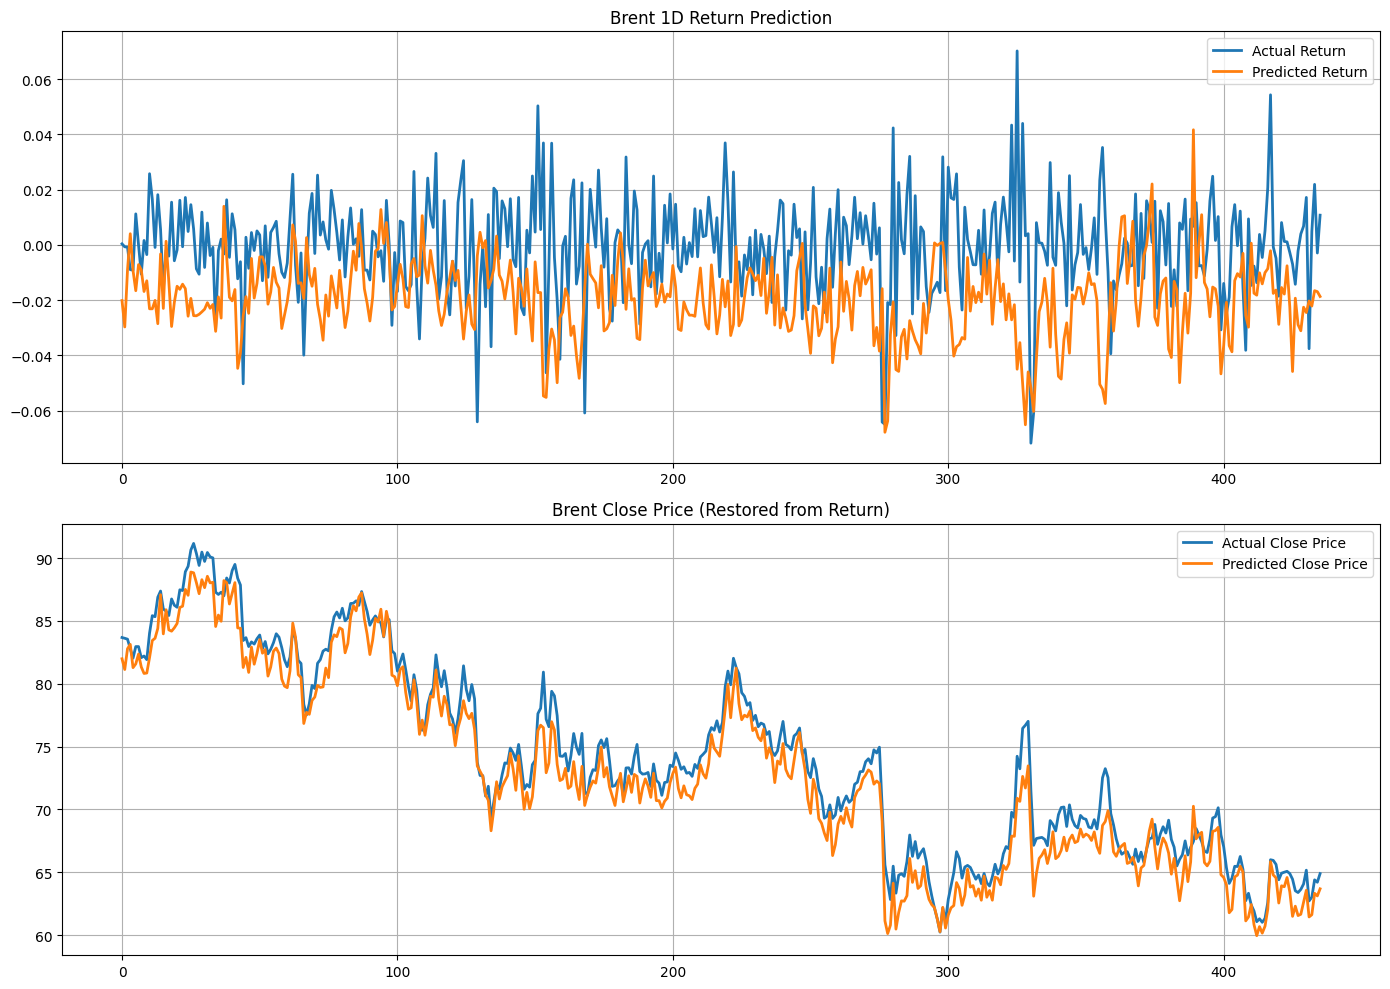


===== Running G =====
[Epoch 01] train=0.30120, val=0.02757
[Epoch 02] train=0.06959, val=0.01704
[Epoch 03] train=0.05426, val=0.01671
[Epoch 04] train=0.04913, val=0.01829
[Epoch 05] train=0.05147, val=0.01540
[Epoch 06] train=0.06061, val=0.01352
[Epoch 07] train=0.04098, val=0.01517
[Epoch 08] train=0.03815, val=0.01602
[Epoch 09] train=0.03741, val=0.01405
[Epoch 10] train=0.04798, val=0.01394
[Epoch 11] train=0.04175, val=0.01653
[Epoch 12] train=0.03630, val=0.01291
[Epoch 13] train=0.03412, val=0.01440
[Epoch 14] train=0.03378, val=0.01532
[Epoch 15] train=0.03135, val=0.01496
[Epoch 16] train=0.03207, val=0.01412
[Epoch 17] train=0.03148, val=0.01498
[Epoch 18] train=0.03481, val=0.02058
[Epoch 19] train=0.02933, val=0.01615
[Epoch 20] train=0.02821, val=0.01488
[Epoch 21] train=0.03074, val=0.01886
[Epoch 22] train=0.02955, val=0.01763
[Epoch 23] train=0.02925, val=0.01580
[Epoch 24] train=0.02731, val=0.01542
[Epoch 25] train=0.02710, val=0.01629
[Epoch 26] train=0.02584, v

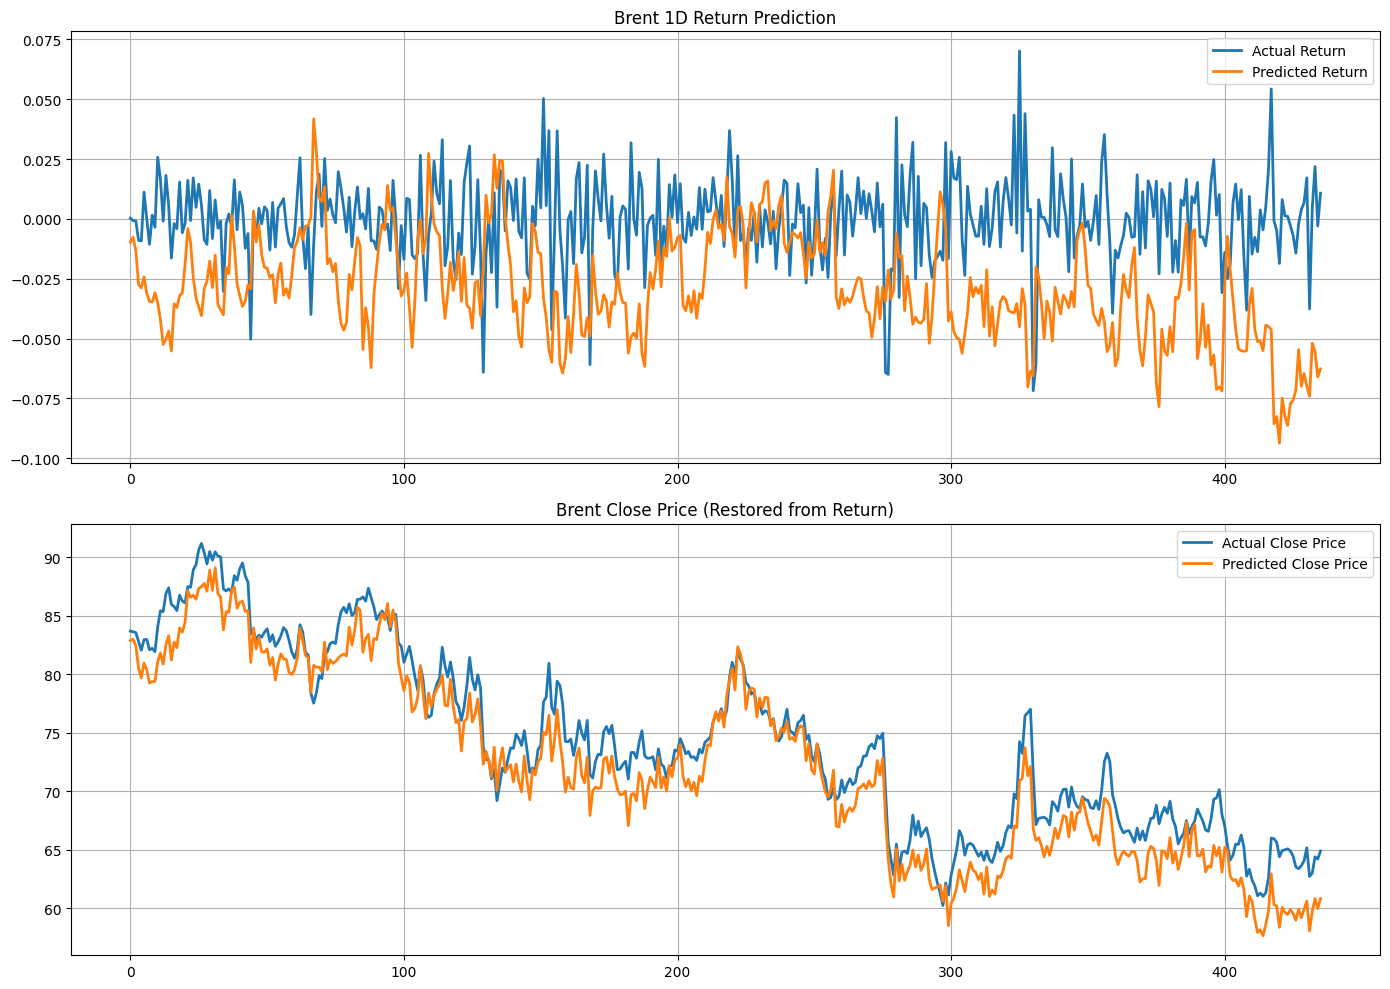


===== Running H =====
[Epoch 01] train=0.15801, val=0.06005
[Epoch 02] train=0.06306, val=0.04744
[Epoch 03] train=0.05497, val=0.01993
[Epoch 04] train=0.05487, val=0.02200
[Epoch 05] train=0.04476, val=0.03933
[Epoch 06] train=0.04686, val=0.01505
[Epoch 07] train=0.04206, val=0.01779
[Epoch 08] train=0.04271, val=0.01827
[Epoch 09] train=0.03800, val=0.02332
[Epoch 10] train=0.04314, val=0.02476
[Epoch 11] train=0.04528, val=0.01274
[Epoch 12] train=0.04353, val=0.02056
[Epoch 13] train=0.03414, val=0.01870
[Epoch 14] train=0.03543, val=0.01622
[Epoch 15] train=0.03562, val=0.01131
[Epoch 16] train=0.03121, val=0.01266
[Epoch 17] train=0.02937, val=0.01138
[Epoch 18] train=0.03128, val=0.01670
[Epoch 19] train=0.02980, val=0.01366
[Epoch 20] train=0.03006, val=0.01414
[Epoch 21] train=0.02873, val=0.01267
[Epoch 22] train=0.02790, val=0.01339
[Epoch 23] train=0.02624, val=0.01229
[Epoch 24] train=0.02617, val=0.01316
[Epoch 25] train=0.02571, val=0.01351
[Epoch 26] train=0.02452, v

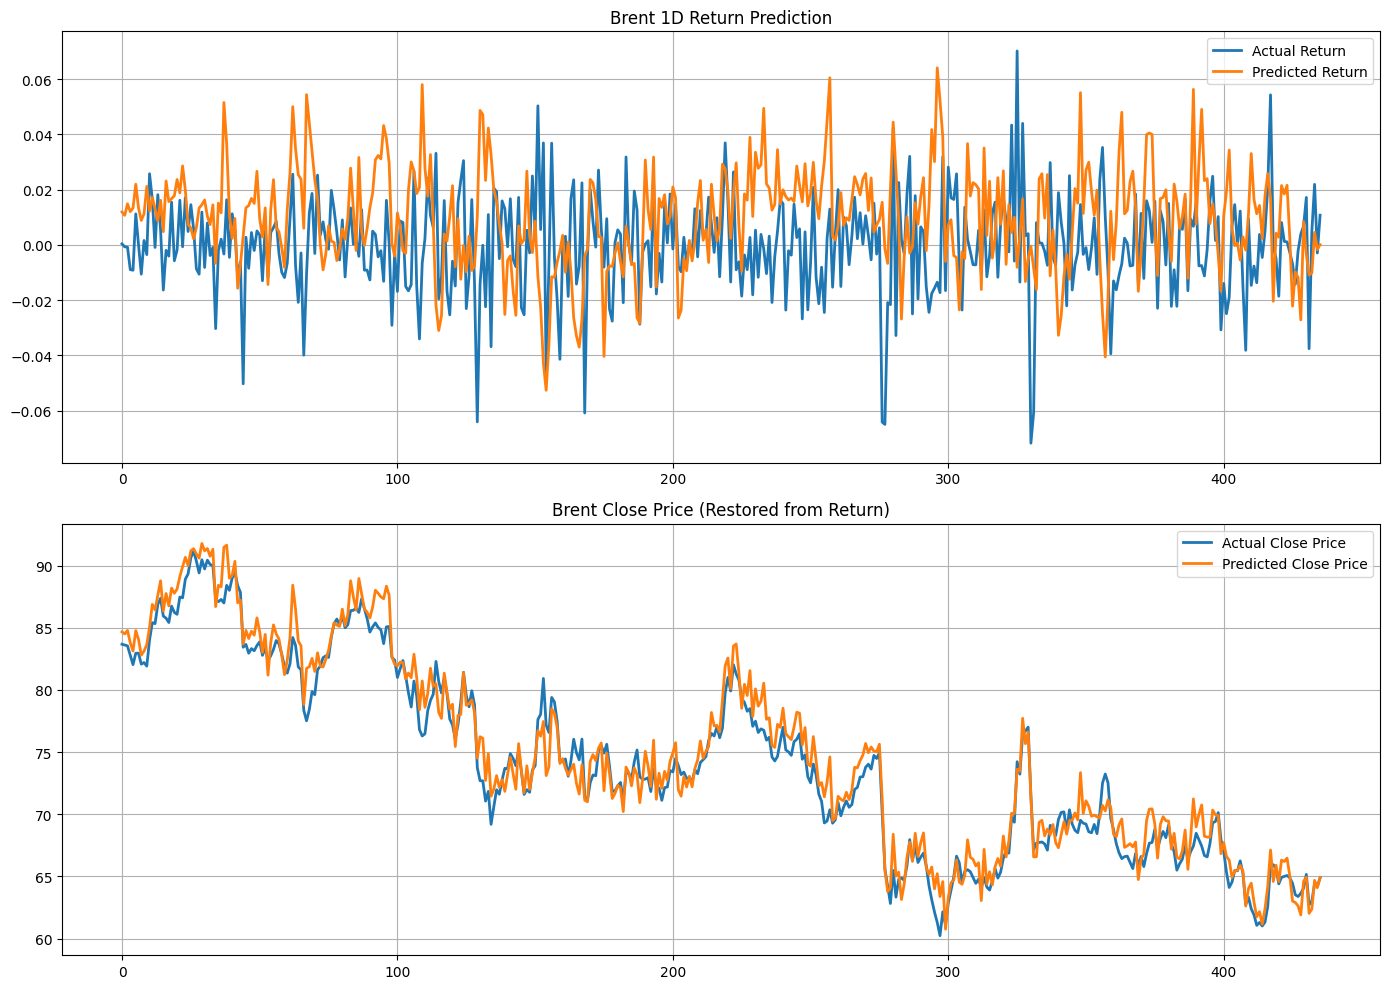

In [99]:
feature_sets = make_feature_sets(
    base_A = features,          # A: Brent+WTI 기본
    features_eia = features_b,  # B: A+EIA
    features_cot = df_final,    # D: A+EIA+COT
    features_news = features_E  # E: A+NEWS
)

for name, df in feature_sets.items():
    print(f"\n===== Running {name} =====")
    df = df.dropna()
    result = run_bigru_pipeline(df)
    result


# 클러스터링 기반

In [116]:
def prepare_timeseries_df(df):
    """
    CSV로부터 읽은 raw DF에서
    Date → datetime 변환 + index 설정 + 소트 + 중복 제거까지 처리
    """
    df = df.copy()

    # 1) Date 컬럼 이름이 'Date' 또는 'date' 뭐든 자동 처리
    date_col = None
    for c in df.columns:
        if c.lower() == "date":
            date_col = c
            break

    if date_col is None:
        raise KeyError("Date 컬럼을 찾지 못했습니다. 'Date' 또는 'date' 이름이어야 합니다.")

    # 2) 날짜 변환
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

    # 3) 날짜가 NaT인 행 제거
    df = df.dropna(subset=[date_col])

    # 4) index 설정
    df = df.set_index(date_col)

    # 5) 타임소트
    df = df.sort_index()

    # 6) index 중복 제거
    df = df[~df.index.duplicated(keep="last")]

    return df

clust=pd.read_csv('checkpoint_1117_with_cluster30_graph_brent_ridge_impact.csv')
df_ts = prepare_timeseries_df(clust)

print(df_ts.head())


            brent_close  wti_close  brent_wti_spread  brent_ret_1d  \
Date                                                                 
2014-01-02   107.779999  95.440002         12.339996     -0.027256   
2014-01-03   106.889999  93.959999         12.930000     -0.008258   
2014-01-06   106.730003  93.430000         13.300003     -0.001497   
2014-01-07   107.349998  93.669998         13.680000      0.005809   
2014-01-08   107.150002  92.330002         14.820000     -0.001863   

            brent_ret_5d  brent_ret_20d  brent_ma_5  brent_ma_20  brent_ma_60  \
Date                                                                            
2014-01-02     -0.036819      -0.032930  110.790001     110.6705   109.391334   
2014-01-03     -0.045455      -0.050879  109.772000     110.3840   109.356167   
2014-01-06     -0.048583      -0.046031  108.682001     110.1265   109.310667   
2014-01-07     -0.034709      -0.032709  107.910001     109.9450   109.271834   
2014-01-08     -0.03294

In [131]:
def attach_cluster_to_A(base_A, features_cluster):
    """
    base_A : 기존 A (Brent + WTI 기본 피처셋)
    features_cluster : cluster, impact 값이 모두 들어있는 DF
    """

    # 필요 컬럼만 추출
    cluster_cols = [
        "cluster_0","cluster_1","cluster_2","cluster_3","cluster_4",
        "cluster_5","cluster_6","cluster_7","cluster_8",
        "news_impact_brent_day0_value","news_impact_brent_day1_value",
        "news_impact_brent_day2_value","news_impact_brent_day3_value",
        "news_impact_brent_day4_value","news_impact_brent_total"
    ]

    cluster_df = features_cluster[cluster_cols].copy()

    # index(Date) 기준 merge
    A_with_cluster = base_A.join(cluster_df, how="left")

    return A_with_cluster


In [132]:
def attach_cluster_to_H(H, features_cluster):
    """
    H : A + EIA + COT + NEWS 풀 피처셋
    features_cluster : cluster + 영향을 포함한 DF
    """

    cluster_cols = [
        "cluster_0","cluster_1","cluster_2","cluster_3","cluster_4",
        "cluster_5","cluster_6","cluster_7","cluster_8",
        "news_impact_brent_day0_value","news_impact_brent_day1_value",
        "news_impact_brent_day2_value","news_impact_brent_day3_value",
        "news_impact_brent_day4_value","news_impact_brent_total"
    ]

    cluster_df = features_cluster[cluster_cols].copy()

    H_with_cluster = H.join(cluster_df, how="left")

    return H_with_cluster


[Epoch 01] train=0.34720, val=0.07788
[Epoch 02] train=0.09001, val=0.03019
[Epoch 03] train=0.06926, val=0.02727
[Epoch 04] train=0.05478, val=0.02616
[Epoch 05] train=0.04660, val=0.02294
[Epoch 06] train=0.05254, val=0.02894
[Epoch 07] train=0.04406, val=0.02056
[Epoch 08] train=0.03724, val=0.01910
[Epoch 09] train=0.03521, val=0.02026
[Epoch 10] train=0.03222, val=0.02393
[Epoch 11] train=0.03232, val=0.01830
[Epoch 12] train=0.03019, val=0.02245
[Epoch 13] train=0.03096, val=0.02096
[Epoch 14] train=0.02852, val=0.02099
[Epoch 15] train=0.02783, val=0.02233
[Epoch 16] train=0.02683, val=0.01907
[Epoch 17] train=0.02385, val=0.02239
[Epoch 18] train=0.02868, val=0.01839
[Epoch 19] train=0.02435, val=0.01900
[Epoch 20] train=0.02157, val=0.02288
[Epoch 21] train=0.02290, val=0.01880
[Epoch 22] train=0.02056, val=0.02059
[Epoch 23] train=0.01912, val=0.01902
[Epoch 24] train=0.02062, val=0.01959
[Epoch 25] train=0.01923, val=0.01955
[Epoch 26] train=0.01920, val=0.01803
[Epoch 27] t

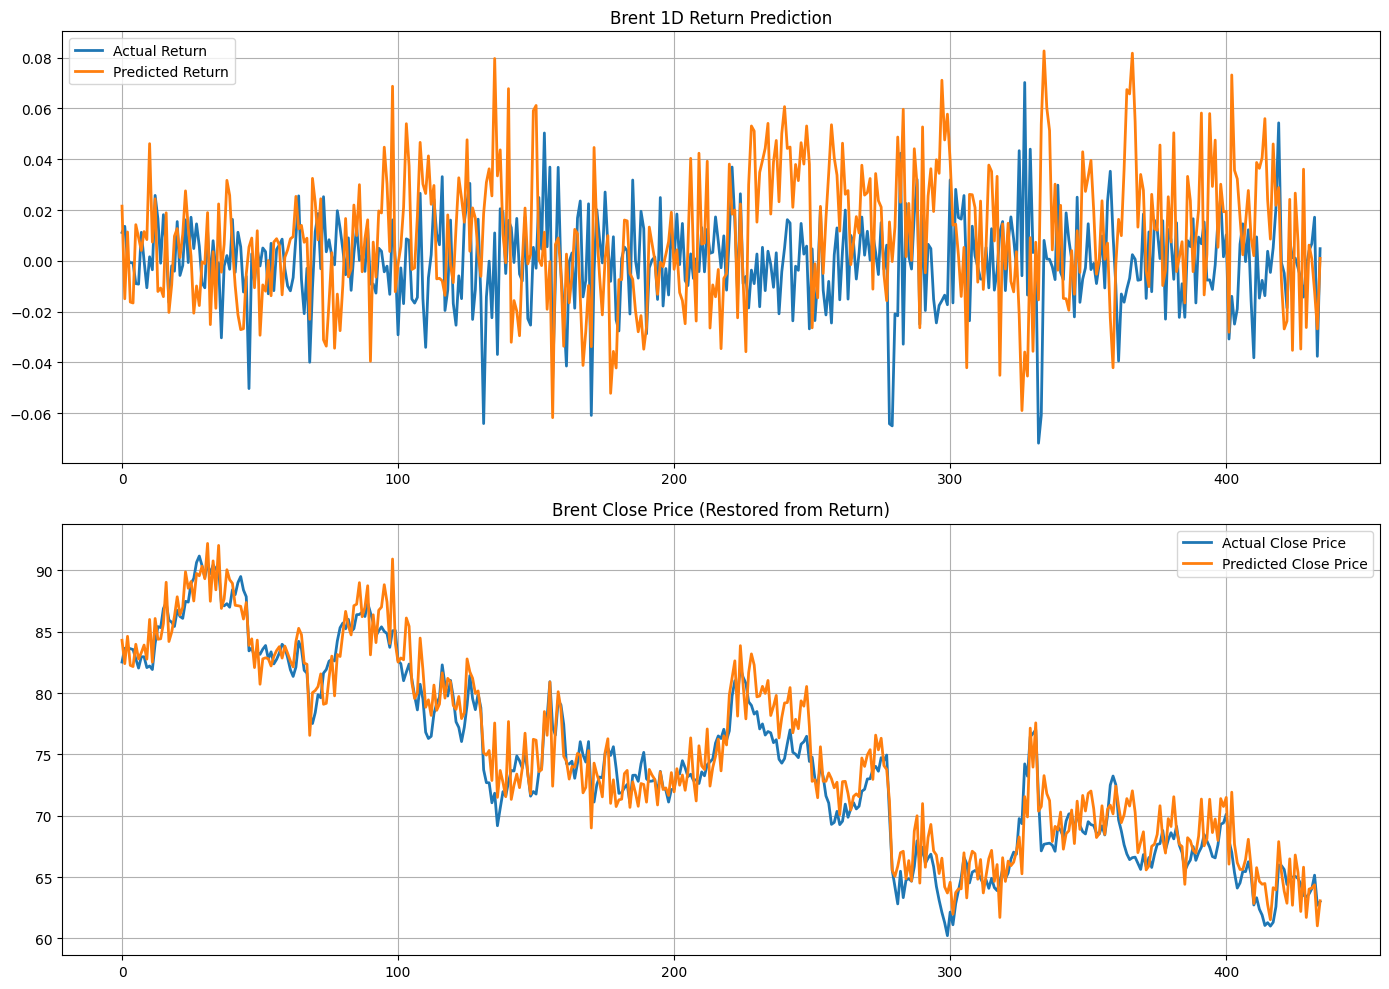

{'model': BiGRU(
   (gru): GRU(54, 64, batch_first=True, bidirectional=True)
   (fc): Linear(in_features=128, out_features=1, bias=True)
 ),
 'metrics': {'rmse': np.float64(0.03246362400941327),
  'mae': 0.025832784111625755,
  'direction_accuracy': np.float64(0.5218390804597701)},
 'prediction': {'y_test': array([ 0.01114918,  0.01357086,  0.00035862, -0.00071699, -0.00083712,
         -0.00897666, -0.00917877,  0.01121402,  0.        , -0.01060749,
          0.00158379, -0.00352756,  0.02575684,  0.0165417 , -0.00093657,
          0.01816268,  0.00563929, -0.0163653 , -0.00197787, -0.00408019,
          0.01545124, -0.00576369, -0.00185511,  0.01614598, -0.00068593,
          0.01715855,  0.00483581,  0.01454956,  0.00573631, -0.00866514,
         -0.01062181,  0.01185423, -0.00817866,  0.00791174, -0.00386952,
         -0.00088792, -0.03032655, -0.0020621 ,  0.00206636, -0.00332227,
          0.01632182, -0.00452388,  0.01124751,  0.00550498, -0.01229049,
         -0.00610861, -0.05

In [133]:
# A + Cluster
A_with_cluster = attach_cluster_to_A(features, df_ts)

# H + Cluster
H_with_cluster = attach_cluster_to_H(H, df_ts)

# GRU 학습
result = run_bigru_pipeline(H_with_cluster.dropna())
result

[Epoch 01] train=0.17161, val=0.02050
[Epoch 02] train=0.06807, val=0.01476
[Epoch 03] train=0.05787, val=0.01240
[Epoch 04] train=0.05886, val=0.01329
[Epoch 05] train=0.04267, val=0.01275
[Epoch 06] train=0.03627, val=0.01147
[Epoch 07] train=0.03956, val=0.01244
[Epoch 08] train=0.03861, val=0.01117
[Epoch 09] train=0.03823, val=0.01217
[Epoch 10] train=0.03207, val=0.00985
[Epoch 11] train=0.03179, val=0.01065
[Epoch 12] train=0.02981, val=0.01087
[Epoch 13] train=0.03038, val=0.01132
[Epoch 14] train=0.02924, val=0.01197
[Epoch 15] train=0.02928, val=0.01167
[Epoch 16] train=0.02824, val=0.01259
[Epoch 17] train=0.03400, val=0.01625
[Epoch 18] train=0.03078, val=0.01044
[Epoch 19] train=0.03283, val=0.01047
[Epoch 20] train=0.02897, val=0.01142
[Epoch 21] train=0.02812, val=0.01217
[Epoch 22] train=0.03190, val=0.01050
[Epoch 23] train=0.02896, val=0.01170
[Epoch 24] train=0.02998, val=0.01123
[Epoch 25] train=0.02511, val=0.01138
[Epoch 26] train=0.02324, val=0.01196
[Epoch 27] t

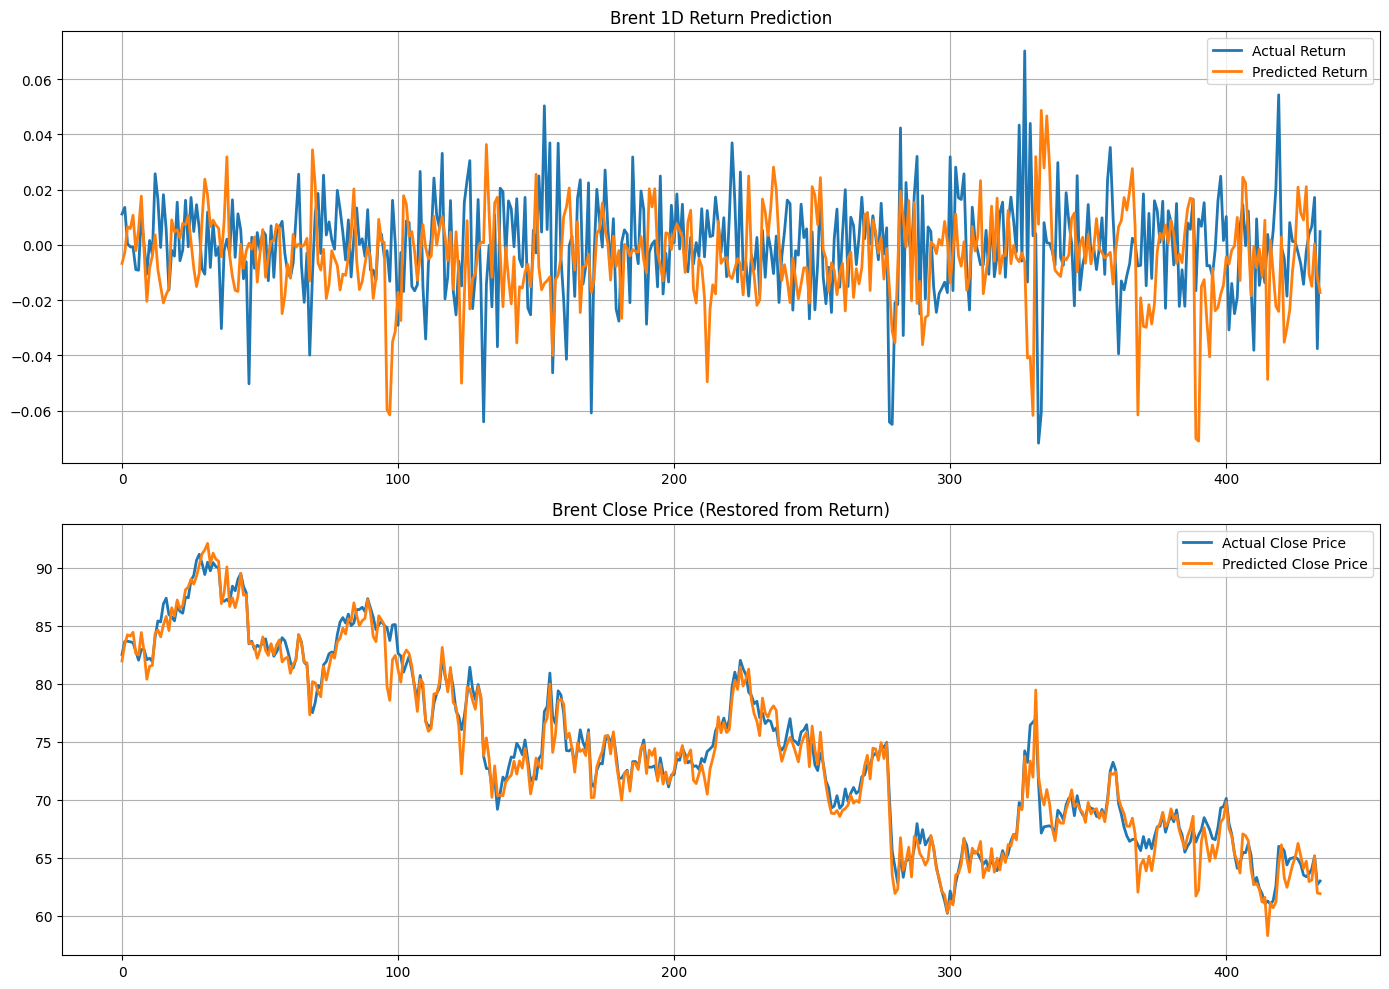

{'model': BiGRU(
   (gru): GRU(30, 64, batch_first=True, bidirectional=True)
   (fc): Linear(in_features=128, out_features=1, bias=True)
 ),
 'metrics': {'rmse': np.float64(0.024554415145410024),
  'mae': 0.01866656398001361,
  'direction_accuracy': np.float64(0.5011494252873563)},
 'prediction': {'y_test': array([ 0.01114918,  0.01357086,  0.00035862, -0.00071699, -0.00083712,
         -0.00897666, -0.00917877,  0.01121402,  0.        , -0.01060749,
          0.00158379, -0.00352756,  0.02575684,  0.0165417 , -0.00093657,
          0.01816268,  0.00563929, -0.0163653 , -0.00197787, -0.00408019,
          0.01545124, -0.00576369, -0.00185511,  0.01614598, -0.00068593,
          0.01715855,  0.00483581,  0.01454956,  0.00573631, -0.00866514,
         -0.01062181,  0.01185423, -0.00817866,  0.00791174, -0.00386952,
         -0.00088792, -0.03032655, -0.0020621 ,  0.00206636, -0.00332227,
          0.01632182, -0.00452388,  0.01124751,  0.00550498, -0.01229049,
         -0.00610861, -0.05

In [134]:
result = run_bigru_pipeline(A_with_cluster.dropna())
result